In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json, select_random_json, read_experiment_json
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [30]:
results = "../results/parameters_effects"
create_folder(results)

Folder created: ../results/parameters_effects


In [2]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df

,type_perc,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,bond,2,128,2,0.00001,1,1.00,1.0,0.1,1,600,0.848791,4.945353e-05,130.770000,0.039057,1.572435e+04,5.101384
1,bond,2,128,5,0.00001,1,1.00,1.0,0.1,1,600,0.852570,4.775880e-05,130.631667,0.036682,1.572423e+04,4.842578
2,bond,2,256,5,0.00001,1,1.00,1.0,0.1,1,306,0.473092,3.871623e-04,342.960784,1.033260,5.461678e+04,37.916007
3,bond,2,128,7,0.00001,1,1.00,1.0,0.1,1,600,0.855112,4.699257e-05,130.541667,0.038797,1.572483e+04,5.188671
4,bond,2,128,10,0.00001,1,1.00,1.0,0.1,1,600,0.858670,4.852395e-05,130.370000,0.037294,1.571651e+04,5.113005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5389,bond,3,256,15728,0.00010,4,0.25,1.0,0.1,4,100,0.890501,3.694067e-04,262.710000,0.047768,2.557583e+06,136308.624713
5390,bond,3,256,16384,0.00010,4,0.25,1.0,0.1,1,100,0.999976,7.570817e-06,255.000000,0.000000,3.350539e+04,3224.601414
5391,bond,3,256,16384,0.00010,4,0.25,1.0,0.1,2,100,0.999973,8.685430e-06,255.000000,0.000000,2.521069e+04,2677.266900
5392,bond,3,256,16384,0.00010,4,0.25,1.0,0.1,3,100,0.999956,1.205548e-05,255.000000,0.000000,2.046540e+04,2358.293506


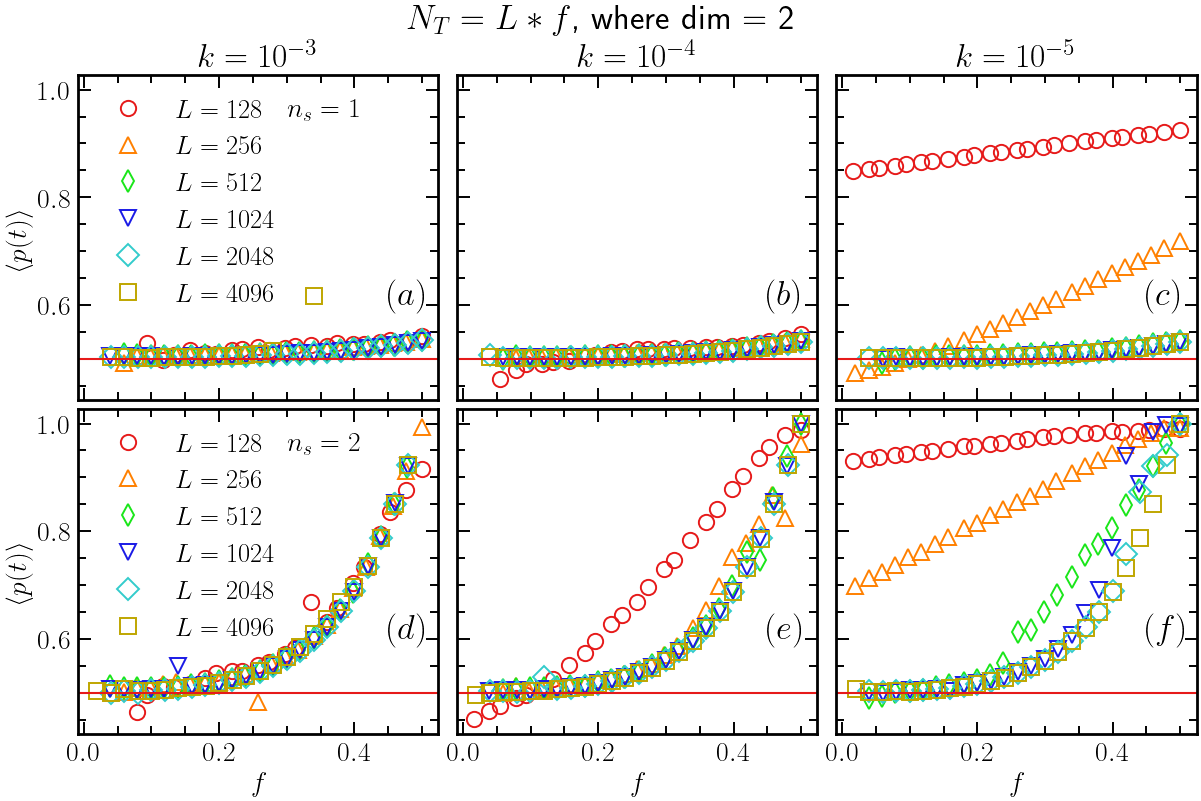

In [31]:
L_lst = [128, 256, 512, 1024, 2048, 4096]
nc_lst = [1,2]
k_lst=[1.0e-03, 1.0e-04, 1.0e-05]
base = 4
fig, axes = plt.subplots(
    2, 3, figsize=(3*base, 2*base),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.5
#rho = 1/nc
dim = 2
colors = [
    (0.9, 0.1, 0.1),   # red
    (1.0, 0.5, 0.0),   # orange
    (0.1, 0.9, 0.1),   # green
    (0.1, 0.1, 0.9),   # blue
    (0.2, 0.8, 0.8),   # teal
    (0.75,0.65, 0.00),   # yellow
    (0.6, 0.4, 0.2),   # brown
    (0.6, 0.2, 0.8),   # purple
    (0.9, 0.4, 0.7),   # pink
    (0.4, 0.4, 0.4),   # gray
    (0.0, 0.0, 0.0),   # black
]
markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]

fs_title_figure = 25
fs_legend = 19
ms = 11
mew = 1.4
labels = ["$(a)$", "$(b)$", "$(c)$",
          "$(d)$", "$(e)$", "$(f)$"]

for idx_nc, nc in enumerate(nc_lst):
    for idx, k in enumerate(k_lst):
        for idx_L, L in enumerate(L_lst):
            rho = 1/nc
            df_sub = df[(df['dim']==dim) & (df['nc']==nc) & (df['L']==L) & (df['k']==k) & (df['order']==1)]
            f = [i/L for i in df_sub["Nt"].unique()]
            p = df_sub['p_mean']
            axes[idx_nc, idx].plot(f, p, marker=markers[idx_L], color=colors[idx_L], 
                            ls="None", ms=ms, mew=mew,label=f'$L = {L}$')
            
            mantissa, exp = f"{k:.1e}".split("e")
            exp = int(exp)
            
for idx, ax in enumerate(axes.flatten()):
    ax.axhline(y=pc)
    
    ax.text(0.45, 0.60, labels[idx], fontsize=25)

for idx, ax in enumerate(axes[:,0]):
    ax.legend(fontsize=fs_legend)
    ax.set_ylabel(r"$\langle p(t) \rangle$")
    ax.text(0.3, 0.95, f'$n_s = {nc_lst[idx]}$', fontsize=20)
    
for ax in axes[1,:]:
    ax.set_xlabel('$f$')
for idx, ax in enumerate(axes[0,:]):
    mantissa, exp = f"{k_lst[idx]:.1e}".split("e")
    ax.set_title(f"$k = 10^{{{int(exp)}}}$")

# axes[1,0].legend(fontsize=fs_legend)
# axes[1,0].set_ylabel(r"$\langle p(t) \rangle$")

fig.suptitle(fr"$N_T = L * f$, where dim = {dim}", fontsize=fs_title_figure)
plt.savefig(results + f"/f_dim_{dim}.pdf")
plt.show()

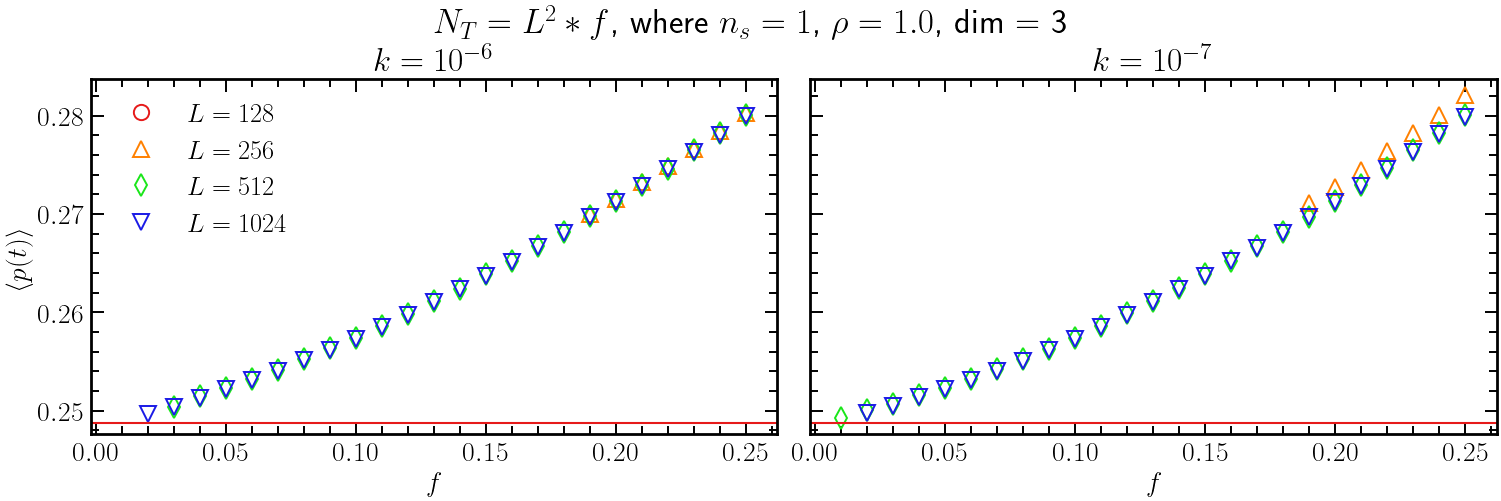

In [66]:
L_lst = [128, 256, 512, 1024]
nc = 1
#k_lst=[1.0e-04, 1.0e-05, 1.0e-06, 1.0e-07]
k_lst=[1.0e-06, 1.0e-07]
fig, axes = plt.subplots(
    1, 2, figsize=(15, 5),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.2488
rho = 1/nc
dim = 3
colors = [
    (0.9, 0.1, 0.1),   # red
    (1.0, 0.5, 0.0),   # orange
    (0.1, 0.9, 0.1),   # green
    (0.1, 0.1, 0.9),   # blue
    (0.2, 0.8, 0.8),   # teal
    (0.75,0.65, 0.00),   # yellow
    (0.6, 0.4, 0.2),   # brown
    (0.6, 0.2, 0.8),   # purple
    (0.9, 0.4, 0.7),   # pink
    (0.4, 0.4, 0.4),   # gray
    (0.0, 0.0, 0.0),   # black
]
markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]

fs_title_figure = 25
fs_legend = 19
ms = 11
mew = 1.4

for idx, k in enumerate(k_lst):
    for idx_L, L in enumerate(L_lst):
        df_sub = df[(df['dim']==dim) & (df['nc']==nc) & (df['L']==L) & (df['k']==k) & (df['order']==1) & (df['P0']==0.1) & (df['p0']==1.0)]
        
        f = [i/L**2 for i in df_sub["Nt"].unique()]
        p = df_sub['p_mean']
        
        axes[idx].plot(f, p, marker=markers[idx_L], color=colors[idx_L], 
                        ls="None", ms=ms, mew=mew,label=f'$L = {L}$')
        
        mantissa, exp = f"{k:.1e}".split("e")
        exp = int(exp)
        axes[idx].set_title(f"$k = 10^{{{exp}}}$")

for ax in axes:
    ax.axhline(y=pc)
    ax.set_xlabel('$f$')
axes[0].legend(fontsize=fs_legend)
axes[0].set_ylabel(r"$\langle p(t) \rangle$")

fig.suptitle(fr"$N_T = L^2 * f$, where $n_s = {nc}$, $\rho={rho}$, dim = {dim}", fontsize=fs_title_figure)
plt.show()

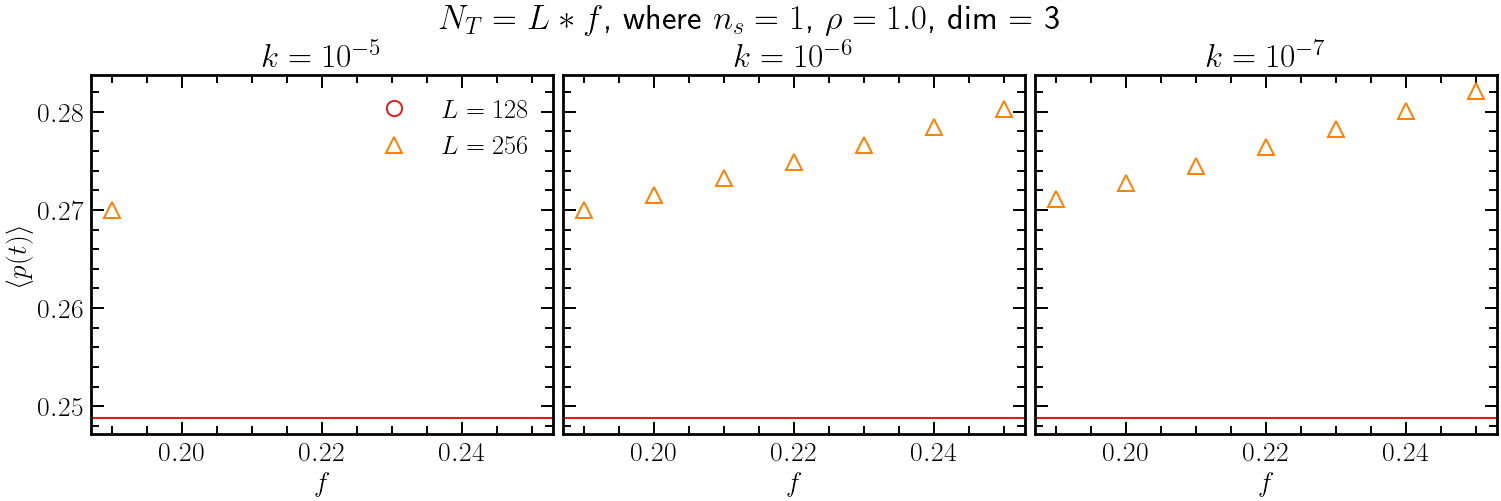

In [65]:
L_lst = [128, 256]
nc = 1
#k_lst=[1.0e-04, 1.0e-05, 1.0e-06, 1.0e-07]
k_lst=[1.0e-05, 1.0e-06, 1.0e-07]
fig, axes = plt.subplots(
    1, 3, figsize=(15, 5),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.2488
rho = 1/nc
dim = 3
colors = [
    (0.9, 0.1, 0.1),   # red
    (1.0, 0.5, 0.0),   # orange
    (0.1, 0.9, 0.1),   # green
    (0.1, 0.1, 0.9),   # blue
    (0.2, 0.8, 0.8),   # teal
    (0.75,0.65, 0.00),   # yellow
    (0.6, 0.4, 0.2),   # brown
    (0.6, 0.2, 0.8),   # purple
    (0.9, 0.4, 0.7),   # pink
    (0.4, 0.4, 0.4),   # gray
    (0.0, 0.0, 0.0),   # black
]
markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]

fs_title_figure = 25
fs_legend = 19
ms = 11
mew = 1.4

for idx, k in enumerate(k_lst):
    for idx_L, L in enumerate(L_lst):
        df_sub = df[(df['dim']==dim) & (df['nc']==nc) & (df['L']==L) & (df['k']==k) & (df['order']==1) & (df['P0']==0.1) & (df['p0']==1.0)]
        
        f = [i/L**2 for i in df_sub["Nt"].unique()]
        p = df_sub['p_mean']
        
        axes[idx].plot(f, p, marker=markers[idx_L], color=colors[idx_L], 
                        ls="None", ms=ms, mew=mew,label=f'$L = {L}$')
        
        mantissa, exp = f"{k:.1e}".split("e")
        exp = int(exp)
        axes[idx].set_title(f"$k = 10^{{{exp}}}$")

for ax in axes:
    ax.axhline(y=pc)
    ax.set_xlabel('$f$')
axes[0].legend(fontsize=fs_legend)
axes[0].set_ylabel(r"$\langle p(t) \rangle$")

fig.suptitle(fr"$N_T = L * f$, where $n_s = {nc}$, $\rho={rho}$, dim = {dim}", fontsize=fs_title_figure)
plt.show()

## $n_c = 1$ and dim $= 2$ ===========================================

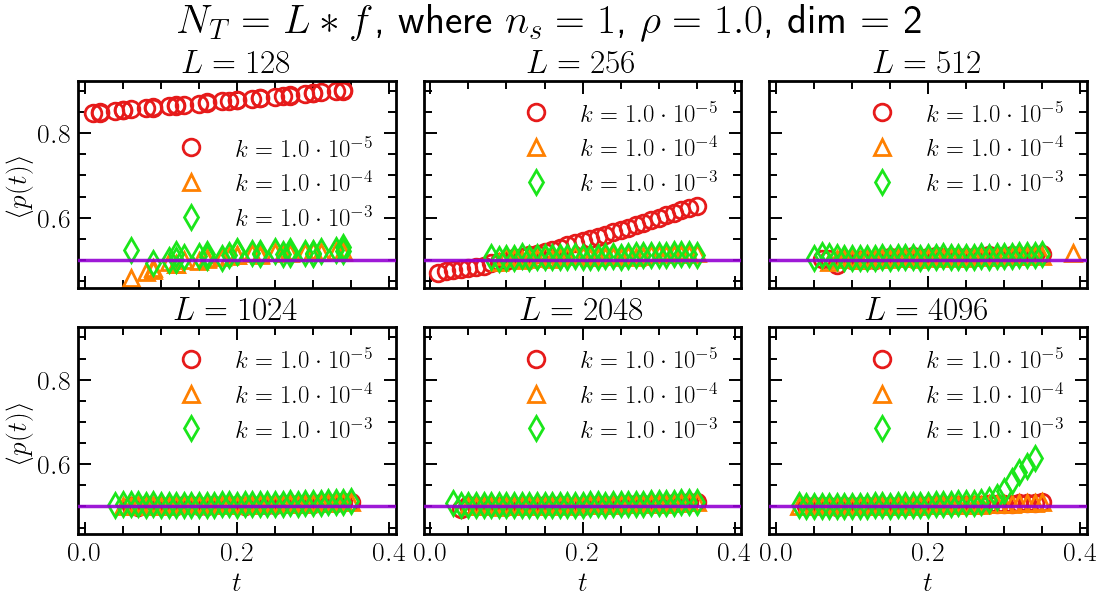

In [6]:

dim = 2
nc = 1
rho = 1/nc
k_lst = [1.e-05, 1.e-04, 1.e-03]
ord = 1

colors = [
    (0.9, 0.1, 0.1),   # red
    (1.0, 0.5, 0.0),   # orange
    (0.1, 0.9, 0.1),   # green
    (0.1, 0.1, 0.9),   # blue
    (0.2, 0.8, 0.8),   # teal
    (0.75,0.65, 0.00),   # yellow
    (0.6, 0.4, 0.2),   # brown
    (0.6, 0.2, 0.8),   # purple
    (0.9, 0.4, 0.7),   # pink
    (0.4, 0.4, 0.4),   # gray
    (0.0, 0.0, 0.0),   # black
]
ord = 1

fig, axes = plt.subplots(
    2, 3, figsize=(11, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
L_lst = [128, 256, 512, 1024, 2048, 4096]

markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 18
fs_label = 25
fs_text = 30
fs_title_figure = 30

for ax, L in zip(axes.flat, L_lst):
    for idx, k in enumerate(k_lst):
        A = L
        df_sub = df[
            (df['L'] == L) &
            (df['nc'] == nc) &
            (df['dim'] == dim) &
            (df['k'] == k)
        ].sort_values("Nt")
        
        
        if df_sub.empty:
            print(f"[WARN] Nenhum dado encontrado para k = {k}")
            continue

        f_list = (df_sub["Nt"] / A).round(2).to_list()
        pk_list = df_sub["p_mean"].to_list()


        index = df_sub["p_mean"].idxmin()
        f_min = round(df_sub.loc[index, "Nt"] / A, 2)
        p_min = df_sub.loc[index, "p_mean"]

        #print(rf"minimum value for k={k}, $\langle p \rangle$ = {p_min} for f = {f_min}")

        mantissa, exp = f"{k:.1e}".split("e")
        exp = int(exp)
        #print(k)
        ax.plot(
            f_list, pk_list,
            marker=markers[idx],
            color=colors[idx],
            ls="None",
            mew=mew,
            ms=ms,
            label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
        )
        ax.set_title(f"$L = {L}$")

pc = 0.5
for ax in axes.flat:
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    ax.legend(fontsize=fs_legend)
for ax in axes[:,0]:
    ax.set_ylabel(r'$\langle p(t) \rangle$')

for ax in axes[1,:]:
    ax.set_xlabel(r'$t$')

fig.suptitle(fr"$N_T = L * f$, where $n_s = {nc}$, $\rho={rho}$, dim = {dim}", fontsize=fs_title_figure)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (2,) and (4,)

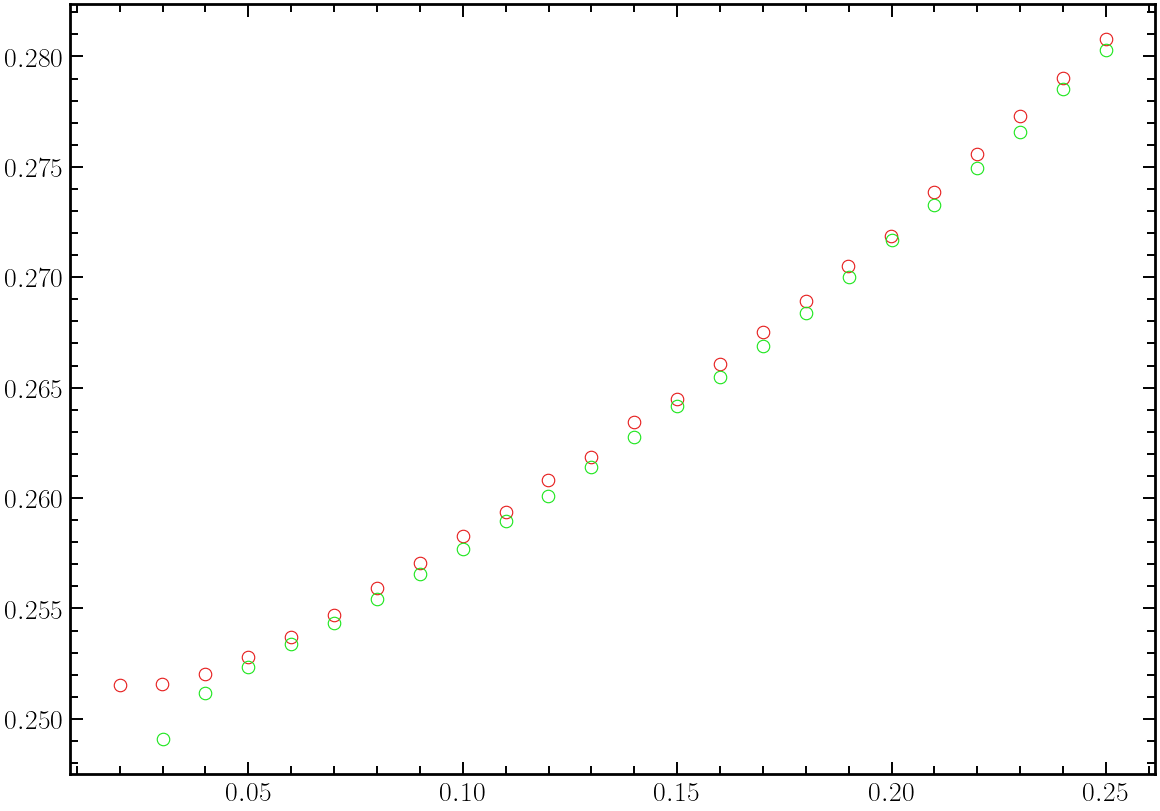

In [7]:
L_lst = [128, 256, 512, 1024]
k = 1.0e-5
for L in L_lst:
    df_sub = df[(df['L']==L) & (df['nc']==1) & (df['dim']==3) & (df['k']==k)]
    f = [i/L**2 for i in df_sub['Nt'].unique()]
    pt = df_sub['p_mean']
    plt.plot(f, pt, 'o', label=f'$L = {L}$')
plt.legend()
plt.show()

minimum value i=1, $\rho$ = 0.2573269063165011 for f = 0.02
minimum value i=2, $\rho$ = 0.2576364748698694 for f = 0.02
minimum value i=3, $\rho$ = 0.2576327086830466 for f = 0.02
minimum value i=4, $\rho$ = 0.2584986225009401 for f = 0.02
minimum value for k=0.0001, $\langle p \rangle$ = 0.2580537907365092 for f = 0.02
minimum value for k=5e-05, $\langle p \rangle$ = 0.2573269063165011 for f = 0.02
minimum value for k=1e-05, $\langle p \rangle$ = 0.2608058595929577 for f = 0.03
minimum value for k=5e-05, $\langle p \rangle$ = 0.2573269063165011 for f = 0.02
minimum value for k=6e-06, $\langle p \rangle$ = 0.2578709825284015 for f = 0.02


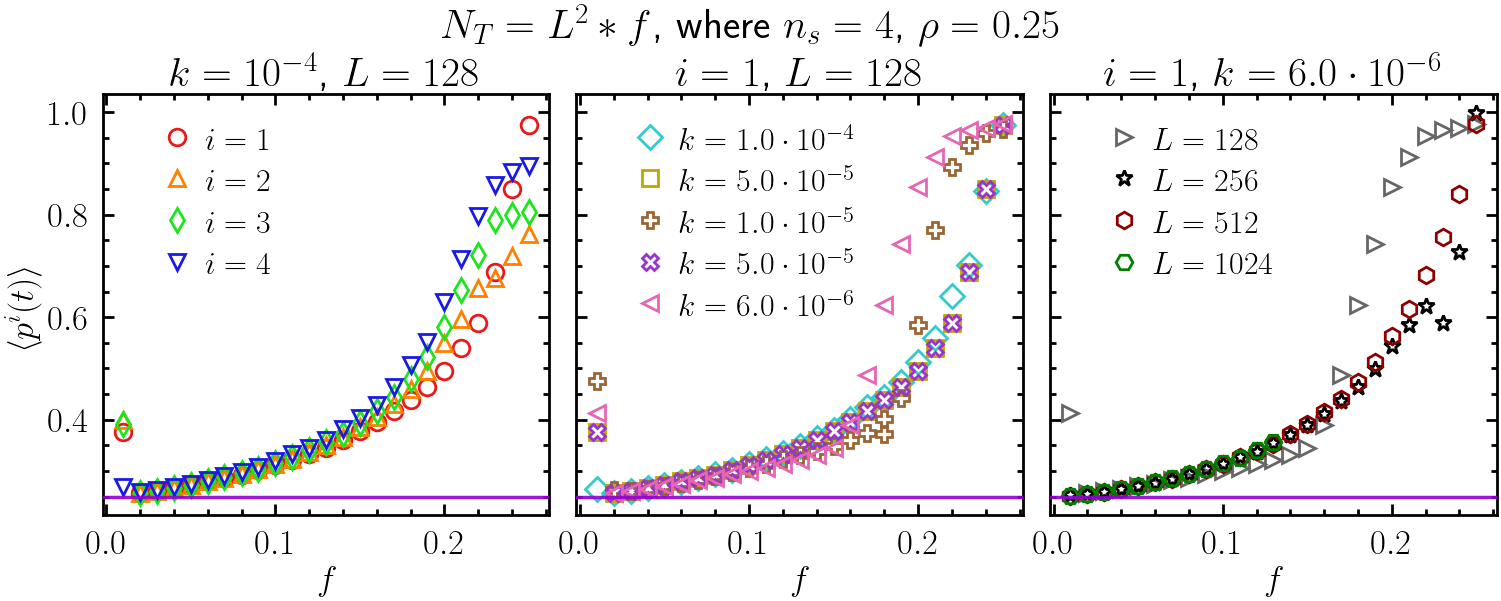

In [10]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 128
nc = 4
dim = 3
rho = 1/nc
A = L**2

orders = [i for i in range(1,nc+1)]

colors = [
    (0.9, 0.1, 0.1),    # red
    (1.0, 0.5, 0.0),    # orange
    (0.1, 0.9, 0.1),    # green
    (0.1, 0.1, 0.9),    # blue
    (0.2, 0.8, 0.8),    # teal
    (0.75, 0.65, 0.00), # yellow
    (0.6, 0.4, 0.2),    # brown
    (0.6, 0.2, 0.8),    # purple
    (0.9, 0.4, 0.7),    # pink
    (0.4, 0.4, 0.4),    # gray
    (0.0, 0.0, 0.0),    # black
    (0.55, 0.0, 0.0),   # dark red
    (0.0, 0.5, 0.0),    # dark green
    (0.0, 0.4, 0.6),    # dark cyan / steel blue
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 3, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*", "h", "H", "p"]
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30

f00 = [round(i, 2) for i in np.arange(0.01, 0.26, 0.01)]
NT_lst_check = [int(L**2 * f) for f in f00]

for idx, ord in enumerate(orders):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k_lst[1])]
    
    f_list = [round(i/A,4) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes[0].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')
print("================")

for idx, k in enumerate(k_lst):
    df_sub = df[
        (df['L'] == L) &
        (df['rho'] == rho) &
        (df['nc'] == nc) &
        (df['dim'] == dim) &
        (df['k'] == k) &
        (df['order'] == 1)
    ].sort_values("Nt")

    if df_sub.empty:
        print(f"[WARN] Nenhum dado encontrado para k = {k}")
        continue

    f_list = (df_sub["Nt"] / A).round(2).to_list()
    pk_list = df_sub["p_mean"].to_list()

    nt_existentes = sorted(df_sub["Nt"].unique().tolist())
    nt_faltando = sorted(set(NT_lst_check) - set(nt_existentes))
    f_faltando = [round(nt / L**2, 2) for nt in nt_faltando]

    # print(f"\nk = {k:.1e}")
    # print("Nt existentes :", nt_existentes)
    # print("Nt faltando   :", nt_faltando)
    # print("f faltando    :", f_faltando)

    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"] / A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value for k={k}, $\langle p \rangle$ = {p_min} for f = {f_min}")

    mantissa, exp = f"{k:.1e}".split("e")
    exp = int(exp)

    axes[1].plot(
        f_list, pk_list,
        marker=markers[len(orders)+idx],
        color=colors[len(orders)+idx],
        ls="None",
        mew=mew,
        ms=ms,
        label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
    )

L_lst = [128, 256, 512, 1024]

for idx, l in enumerate(L_lst):
    ord = 1
    k = 6.0e-6
    mantissa_L, exp_L = f"{k:.1e}".split("e")
    df_sub = df[(df['L']==l) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k)]
    A = l**2
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    axes[2].plot(f_list, pk_list, marker=markers[len(orders) + len(k_lst) + idx], color=colors[len(orders) + len(k_lst) + idx], 
                 ls="None", mew=mew, ms=ms, label=f'$L = {l}$')


for ax in axes:
    leg = ax.legend(
        loc="upper left",
        fontsize=fs_legend,
        bbox_to_anchor=(0.08, 0.98),  # move para direita e levemente para baixo
        frameon=False,
        handletextpad=0.4,   # aproxima símbolo do texto
        labelspacing=0.35,   # reduz espaço vertical
        handlelength=1.0,    # encurta área do símbolo
        handleheight=0.9,
        borderpad=0.2,
        markerscale=1.0
    )
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)

exp = int(f"{k_lst[0]:.0e}".split("e")[1])


axes[0].set_title(f"$k = 10^{{{exp}}}$, $L = {L}$", fontsize=fs_text)
axes[1].set_title(f"$i = 1$, $L = {L}$", fontsize=fs_text)
axes[2].set_title(f"$i = 1$, $k = {mantissa_L} \\cdot 10^{{{-6}}}$", fontsize=fs_text)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
fig.suptitle(fr"$N_T = L^2 * f$, where $n_s = {nc}$, $\rho={rho}$", fontsize=fs_title_figure)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/NT_constant/NT_655/k_6.0e-06/rho_2.5000e-01/properties_mean_bundle.json'

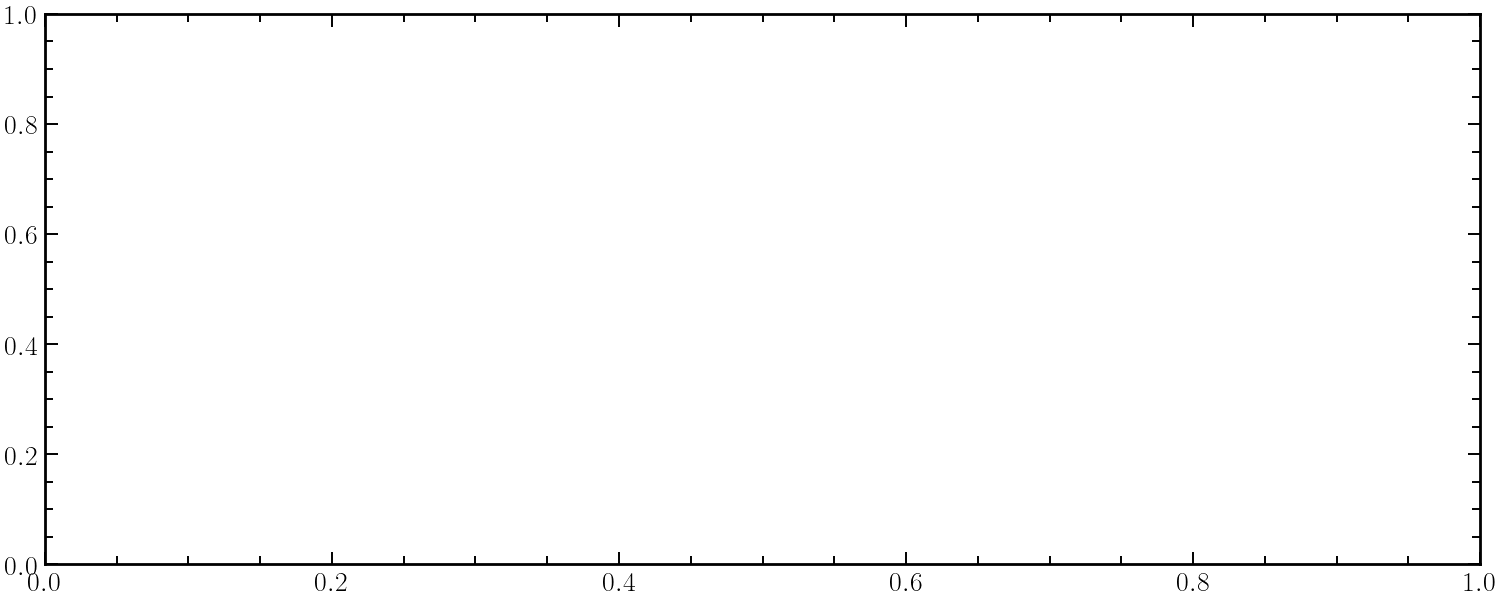

In [19]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 256
nc = 2
dim = 3
rho = 1/nc
A = L**2
k=6.0e-06
Nt = 655
rho = 0.25
# acumula todas as series de TODOS os nc para definir um t_eq GLOBAL por subplot (por L)
all_series = []  # lista de dicts: {nc, i, t, pt, sem}
num_seeds_by_nc = {}

fig, ax = plt.subplots(
    1, 1, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.24881182
orders, num_seeds = read_mean_json(nc, dim, L, Nt, k, rho)
num_seeds_by_nc[nc] = num_seeds

if isinstance(orders, dict):
    if "0" in orders:
        orders = [orders[str(i)] for i in range(nc)]
    else:
        orders = [orders[i] for i in range(nc)]

for i in range(nc):
    d = orders[i]["data"]
    t = np.array(d["time"], dtype=float)
    pt = np.array(d["pt_mean"], dtype=float)
    pt_sem = np.array(d["pt_sem"], dtype=float)
    all_series.append({"nc": nc, "i": i, "t": t, "pt": pt, "sem": pt_sem})

# t_eq: calcula t0 por série e pega o máximo (para usar em todas as curvas do subplot)
t0_ind = []
for s in all_series:
    t, pt, sem = s["t"], s["pt"], s["sem"]
    idx0_i = detect_equilibrium_start_with_errors(
        t, pt, sem, w=40, consec=6, z=2.0, chi2r_max=2.0
    )
    t0_ind.append(float(t[idx0_i]))
t0_global = float(max(t0_ind))

print(f"t0 GLOBAL (usado para TODAS no subplot L={L}): {t0_global:.2f}")
ls = '-'
color = 'k'
lw_dados = 1.4
lw_pc = 1.4
# plot: cor = i, linestyle = nc

for s in all_series:
    nc, i = s["nc"], s["i"]
    t, pt, sem = s["t"], s["pt"], s["sem"]

    ax.plot(t, pt, ls=ls, color=color, lw=lw_dados)
    ax.fill_between(t, pt - sem, pt + sem, alpha=0.12, color=color)

ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

path = f"../SOP_data/raw/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
#random_sample = path + "light_seed_2129561910_ts_20260323T143847_P0_0.10_p0_1.00.json"
random_sample = select_random_json(path, 1.0)
ts = read_experiment_json(random_sample)
t = np.asarray(ts['results']['order_percolation 1']['data']['time'])
pt = np.asarray(ts['results']['order_percolation 1']['data']['pt'])
ax.plot(t, pt)
print(pt)
plt.show()

128 12689    0.474818
12693    0.257786
12697    0.260806
12701    0.265270
12709    0.270412
12713    0.276222
12717    0.282933
12721    0.289598
12729    0.298628
12737    0.305265
12741    0.314115
12745    0.322641
12753    0.331948
12757    0.339539
12761    0.349386
12765    0.360664
12777    0.374455
12781    0.401719
12789    0.371822
12793    0.443057
12797    0.585384
12805    0.770200
12809    0.893138
12813    0.935693
12817    0.959848
12825    0.966433
Name: p_mean, dtype: float64
256 12705    0.252615
12725    0.255541
12749    0.259813
12769    0.264879
12801    0.271125
12821    0.277724
12833    0.285668
12837    0.294005
12845    0.304140
12853    0.315666
12857    0.326568
12865    0.338851
12873    0.353866
12881    0.368879
12885    0.389418
12893    0.412093
12905    0.437637
12909    0.467835
12917    0.502611
12921    0.542178
12933    0.600187
12937    0.651275
12945    0.688890
12949    0.680451
12961    0.992319
Name: p_mean, dtype: float64
512 12773    0.3

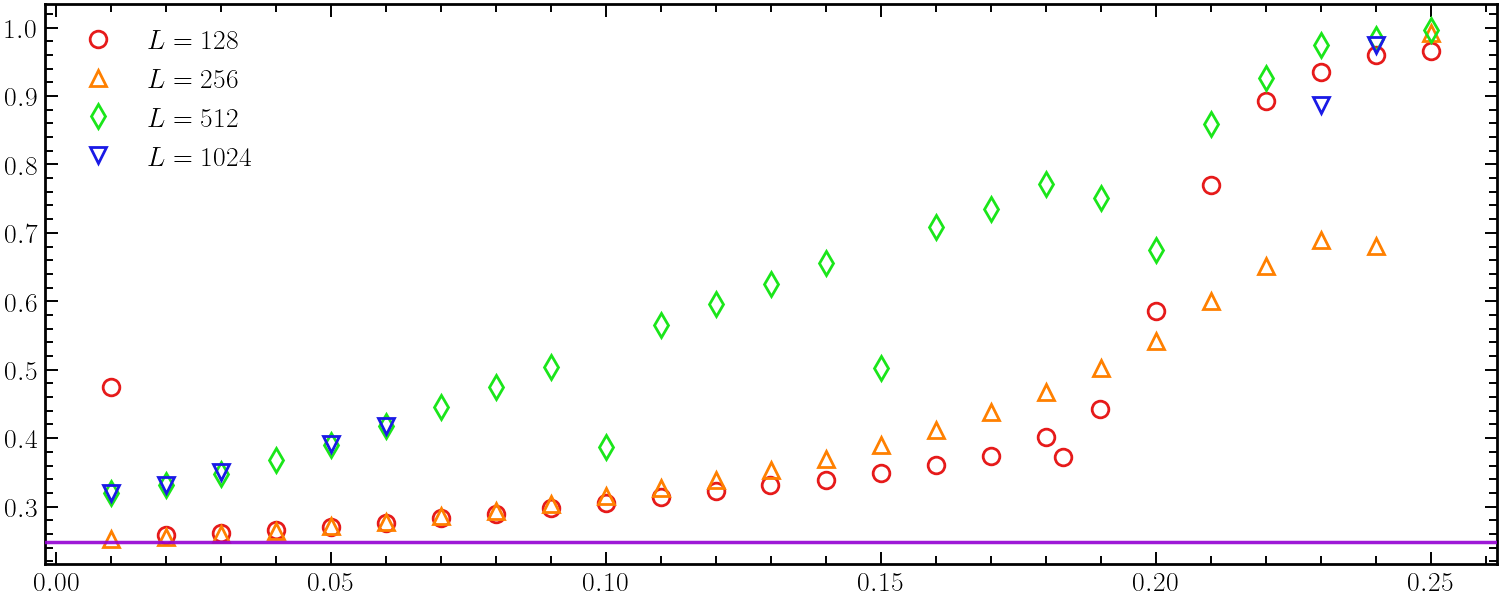

In [6]:
L_lst = [128, 256, 512, 1024]
nc = 4
dim = 3
rho = 1/nc
A = L**2
ord = 1
k = 1.0e-05
fig, axes = plt.subplots(
    1, 1, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.24881182
markers = ["o", "^", "d", "v", 'D']
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30

# for idx, L in enumerate(L_lst):
#     df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k)]
    
#     A = L**2
#     f_list = [round(i/A,4) for i in df_sub['Nt'].unique()]
#     pk_list = df_sub["p_mean"]
#     print(L, pk_list)
#     # index = df_sub["p_mean"].idxmin()
#     # f_min = round(df_sub.loc[index, "Nt"]/A, 2)
#     # p_min = df_sub.loc[index, "p_mean"]

#     # print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
#     axes.plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
#                  ls="None", mew=mew, ms=ms, label=f'$L = {L}$')
for idx, L in enumerate(L_lst):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k)]
    
    A = L**2
    f_list = [round(i/A,4) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    print(L, pk_list)
    # index = df_sub["p_mean"].idxmin()
    # f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    # p_min = df_sub.loc[index, "p_mean"]

    # print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes.plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$L = {L}$')
axes.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)                 
plt.legend()
plt.show()

## $n_c = 4$

minimum value i=1, $\rho$ = 0.2580537907365092 for f = 0.02
minimum value i=2, $\rho$ = 0.2579510957577858 for f = 0.02
minimum value i=3, $\rho$ = 0.2584866042740895 for f = 0.02
minimum value i=4, $\rho$ = 0.2585478737145332 for f = 0.02

k = 1.0e-04
Nt existentes : [163, 327, 491, 655, 819, 983, 1146, 1310, 1474, 1638, 1802, 1966, 2129, 2293, 2457, 2621, 2785, 2949, 3112, 3276, 3440, 3604, 3768, 3932, 4096]
Nt faltando   : []
f faltando    : []
minimum value for k=0.0001, $\langle p \rangle$ = 0.2580537907365092 for f = 0.02

k = 5.0e-05
Nt existentes : [163, 327, 491, 655, 819, 983, 1146, 1310, 1474, 1638, 1802, 1966, 2129, 2293, 2457, 2621, 2785, 2949, 3112, 3276, 3440, 3604, 3768, 3932, 4096]
Nt faltando   : []
f faltando    : []
minimum value for k=5e-05, $\langle p \rangle$ = 0.2573269063165011 for f = 0.02

k = 1.0e-05
Nt existentes : [163, 327, 491, 655, 819, 983, 1146, 1310, 1474, 1638, 1802, 1966, 2129, 2293, 2457, 2621, 2785, 2949, 3000, 3112, 3276, 3440, 3604, 3768, 3932,

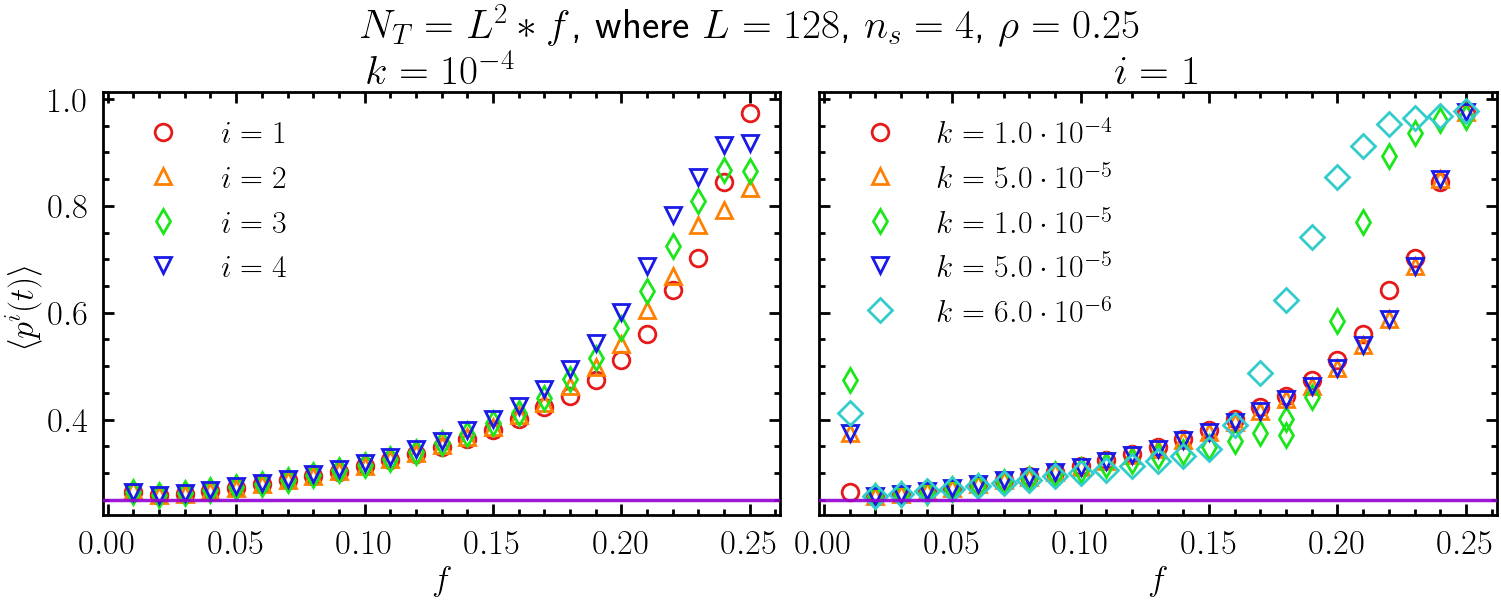

In [ ]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 128
nc = 4
rho = 1/nc
A = L**2

orders = [i for i in range(1,nc+1)]

colors = [
    (0.9, 0.1, 0.1),  # 2 - red
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", 'D']
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30

f00 = [round(i, 2) for i in np.arange(0.01, 0.26, 0.01)]
NT_lst_check = [int(L**2 * f) for f in f00]

for idx, ord in enumerate(orders):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['k']==k_lst[0]) & (df['order']==ord)]
    
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes[0].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')
print("================")

for idx, k in enumerate(k_lst):
    df_sub = df[
        (df['L'] == 128) &
        (df['rho'] == rho) &
        (df['nc'] == nc) &
        (df['k'] == k) &
        (df['order'] == 1)
    ].sort_values("Nt")

    if df_sub.empty:
        print(f"[WARN] Nenhum dado encontrado para k = {k}")
        continue

    f_list = (df_sub["Nt"] / A).round(2).to_list()
    pk_list = df_sub["p_mean"].to_list()

    nt_existentes = sorted(df_sub["Nt"].unique().tolist())
    nt_faltando = sorted(set(NT_lst_check) - set(nt_existentes))
    f_faltando = [round(nt / L**2, 2) for nt in nt_faltando]

    print(f"\nk = {k:.1e}")
    print("Nt existentes :", nt_existentes)
    print("Nt faltando   :", nt_faltando)
    print("f faltando    :", f_faltando)

    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"] / A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value for k={k}, $\langle p \rangle$ = {p_min} for f = {f_min}")

    mantissa, exp = f"{k:.1e}".split("e")
    exp = int(exp)

    axes[1].plot(
        f_list, pk_list,
        marker=markers[idx],
        color=colors[idx],
        ls="None",
        mew=mew,
        ms=ms,
        label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
    )

for ax in axes:
    ax.legend(fontsize=fs_legend)
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)

exp = int(f"{k_lst[0]:.0e}".split("e")[1])


axes[0].set_title(f"$k = 10^{{{exp}}}$", fontsize=fs_text)
axes[1].set_title(f"$i = 1$", fontsize=fs_text)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
fig.suptitle(fr"$N_T = L^2 * f$, where $L = {L}$, $n_s = {nc}$, $\rho={rho}$", fontsize=fs_title_figure)
plt.show()

minimum value i=1, $\rho$ = 0.252652563698962 for f = 0.01
minimum value i=2, $\rho$ = 0.2527609209345247 for f = 0.01
minimum value i=3, $\rho$ = 0.2530461882310697 for f = 0.01
minimum value i=4, $\rho$ = 0.253306166664736 for f = 0.01

k = 1.0e-04
Nt existentes : [655, 1310, 1966, 2621, 3276, 3932, 4587, 5242, 5898, 6553, 7208, 7864, 8519, 15728, 16384]
Nt faltando   : [9175, 9830, 10485, 11141, 11796, 12451, 13107, 13762, 14417, 15073]
f faltando    : [0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23]
minimum value for k=1.0e-04, $\langle p \rangle$ = 0.252652563698962 for f = 0.01

k = 5.0e-05
Nt existentes : [655, 1310, 1966, 2621, 3276, 3932, 4587, 5242, 5898, 6553, 7208, 7864, 8519, 9175, 9830, 10485, 11141, 11796, 12451, 13107, 13762, 14417, 15073, 15728, 16384]
Nt faltando   : []
f faltando    : []
minimum value for k=5.0e-05, $\langle p \rangle$ = 0.2521975805126574 for f = 0.01

k = 1.0e-05
Nt existentes : [655, 1310, 1966, 2621, 3276, 3932, 4587, 5242, 5898, 6553,

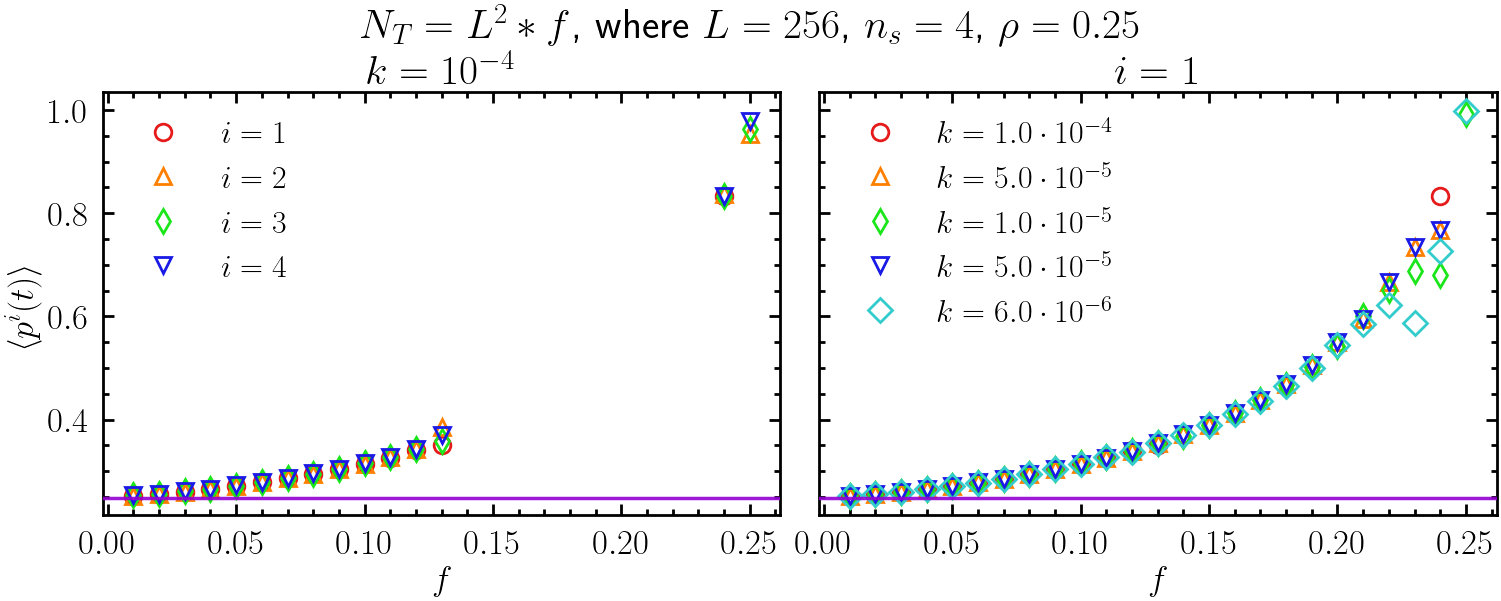

In [ ]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 256
nc = 4
rho = 1/nc
A = L**2

orders = [i for i in range(1,nc+1)]

colors = [
    (0.9, 0.1, 0.1),  # 2 - red
    f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", 'D']
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30
for idx, ord in enumerate(orders):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['k']==k_lst[0]) & (df['order']==ord)]
    
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes[0].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')
print("================")
f00 = [round(i, 2) for i in np.arange(0.01, 0.26, 0.01)]
NT_lst_check = [int(L**2 * f) for f in f00]

for idx, k in enumerate(k_lst):
    df_sub = df[
        (df['L'] == L) &
        (df['rho'] == rho) &
        (df['nc'] == nc) &
        (df['k'] == k) &
        (df['order'] == 1)
    ].sort_values("Nt")

    if df_sub.empty:
        print(f"[WARN] Nenhum dado encontrado para k = {k}")
        continue

    f_list = (df_sub["Nt"] / A).round(2).to_list()
    pk_list = df_sub["p_mean"].to_list()
    
    nt_existentes = sorted(df_sub["Nt"].unique().tolist())
    nt_faltando = sorted(set(NT_lst_check) - set(nt_existentes))
    f_faltando = [round(nt / L**2, 2) for nt in nt_faltando]

    print(f"\nk = {k:.1e}")
    print("Nt existentes :", nt_existentes)
    print("Nt faltando   :", nt_faltando)
    print("f faltando    :", f_faltando)
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"] / A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value for k={k:.1e}, $\langle p \rangle$ = {p_min} for f = {f_min}")

    mantissa, exp = f"{k:.1e}".split("e")
    exp = int(exp)

    axes[1].plot(
        f_list, pk_list,
        marker=markers[idx],
        color=colors[idx],
        ls="None",
        mew=mew,
        ms=ms,
        label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
    )

for ax in axes:
    ax.legend(fontsize=fs_legend)
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)

exp = int(f"{k_lst[0]:.0e}".split("e")[1])


axes[0].set_title(f"$k = 10^{{{exp}}}$", fontsize=fs_text)
axes[1].set_title(f"$i = 1$", fontsize=fs_text)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
fig.suptitle(fr"$N_T = L^2 * f$, where $L = {L}$, $n_s = {nc}$, $\rho={rho}$", fontsize=fs_title_figure)
plt.show()